# Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tqdm import tqdm
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Adjust the width of each column if necessary.
pd.set_option("display.max_colwidth", None)

# Increase the total width of the display
pd.set_option("display.width", 0)

## Paso 1: Recopilación de datos y definición del problema

In [60]:
df = pd.read_csv('../data/raw/demographic_health_data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

`FIPS` - Code for the County  
`TOT_POP` - Total Population (this data as well as all Age and Race data is pulled from the 2019 Population Estimates of the US Census)  
`0-9` - Population aged 0-9 (all of the other age columns are the same but with varying age)  
`0-9 y/o % of total pop` - % of the population aged 0-9  
`10-19 y/o % of total pop`  
`20-29 y/o % of total pop`  
`30-39 y/o % of total pop`  
`40-49 y/o % of total pop`  
`60-69 y/o % of total pop`  
`70-79 y/o % of total pop`  
`80+ y/o % of total pop`  
`White-alone pop` - Population that is White only,All of the other age columns are the same but with varying age  
`% White-alone` - % of population that is White only  
`Black-alone pop`  
`% Black-alone`  
`Native American/American Indian-alone pop`  
`% NA/AI-alone`  
`Asian-alone pop`  
`Hawaiian/Pacific Islander-alone pop`  
`% Hawaiian/PI-alone`  
`Two or more races pop`  
`% Two or more races`  
`N_POP_CHG_2018`- Numeric Change in resident total population 7/1/2017 to 7/1/2018  
`GQ_ESTIMATES_2018` - 7/1/2018 Group Quarters total population estimate  
`R_birth_2018` - Birth rate in period 7/1/2017 to 6/30/2018  
`R_death_2018` - Death rate in period 7/1/2017 to 6/30/2018  
`R_NATURAL_INC_2018`- Natural increase rate in period 7/1/2016 to 6/30/2017  
`R_INTERNATIONAL_MIG_2018`- Net international migration rate in period 7/1/2017 to 6/30/2018  
`R_DOMESTIC_MIG_2018`- Net domestic migration rate in period 7/1/2017 to 6/30/2018  
`R_NET_MIG_2018` - Net migration rate in period 7/1/2017 to 6/30/2018  
`Less than a high school diploma 2014-18`- Education variables are self explanatory, first 4 are number and second 4 are %  
`High school diploma only 2014-18`  
`Some college or associate's degree 2014-18`  
`Bachelor's degree or higher 2014-18`  
`Percent of adults with less than a high school diploma 2014-18`  
`Percent of adults with a high school diploma only 2014-18`  
`Percent of adults completing some college or associate's degree 2014-18`  
`Percent of adults with a bachelor's degree or higher 2014-18`  
`POVALL_2018` - Estimate of people of all ages in poverty 2018  
`PCTPOVALL_2018` - Estimated percent of people of all ages in poverty 2018  
`PCTPOV017_2018` - Estimated percent of people age 0-17 in poverty 2018  
`PCTPOV517_2018`- Estimate of related children age 5-17 in families in poverty 2018  
`MEDHHINC_2018` - Estimate of median household income 2018  
`CI90LBINC_2018` - 90% confidence interval lower bound of estimate of median household income 2018  
`CI90UBINC_2018` -90% confidence interval upper bound of estimate of median household income 2018  
`Civilian_labor_force_2018` - Civilian labor force annual average  
`Employed_2018`- Number employed annual average  
`Unemployed_2018`- Number unemployed annual average  
`Unemployment_rate_2018`- Unemployment rate  
`Med_HH_Income_Percent_of_State_Total_2018` - County Household Median Income as a percent of the State Total Median Household Income, 2018  
`Active Physicians per 100000 Population 2018 (AAMC)` - Total Active Patient Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)`- Active Primary Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)` - Active Patient Care Primary Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Active General Surgeons per 100000 Population 2018 (AAMC)` - Active General Surgeons per 100,000 Population, 2018 (Assumed identical to state)  
`Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)` - Active Patient Care General Surgeons per 100,000 Population, 2018 (Assumed identical to state)  
`Total nurse practitioners (2019)` - Total nurses (2019) - Assumed proportion to fraction of state population living in county  
`Total physician assistants (2019)` - Total physical assistants (2019) - Assumed proportion to fraction of state population living in county  
`Total Hospitals (2019)` - Total Hospitals (2019) (Assumed proportion to fraction of state population living in county)  
`Internal Medicine Primary Care (2019)` - Active Internal Medicine Primary Care Physicians (2019) (Assumed proportion to fraction of state population living in county)  
`Family Medicine/General Practice Primary Care (2019)` - Active Family Medicine/General Practice Primary Care Physicians (2019) (Assumed proportion to fraction of state population living in county)  
`Total Specialist Physicians (2019)`- Sum of Psychiatry, Surgery, Anesthesiology, Emergency Med, Radiology, Cardiology, Oncology, Endocrinology, and Other specialists (2019) (Assumed proportion to fraction of state population living in county  
`ICU Beds_x` - Number of ICU beds per county  
`Population Aged 60+` -Population aged 60+ (all of the other age columns are the same but with varying age)  
`Percent of Population Aged 60+` - % of the population aged 60+  
`STATE_FIPS` - FIPS Code for the State  
`county_pop2018_18 and older` - Population aged 18+ per county in 2018  
`anycondition_prevalence` - A prevalence rate isÂ the total number of cases of a disease existing in a population divided by the total population  
`anycondition_Lower 95% CI` - CI means confidence interval  
`anycondition_Upper 95% CI`  
`anycondition_number` - Population with anycondition  
`Obesity_prevalence`  
`Obesity_Lower 95% CI`  
`Obesity_Upper 95% CI`  
`Obesity_number` - Population with Obesity  
`Heart disease_prevalence`  
`Heart disease_Lower 95% CI`  
`Heart disease_Upper 95% CI`  
`Heart disease_number` - Population with Heart Disease  
`COPD_prevalence`  
`COPD_Lower 95% CI`  
`COPD_Upper 95% CI`  
`COPD_number` - Population with COPD  
`diabetes_prevalence`  
`diabetes_Lower 95% CI`  
`diabetes_Upper 95% CI`  
`diabetes_number` - Population with diabetes  
`CKD_prevalence`  
`CKD_Lower 95% CI`  
`CKD_Upper 95% CI`  
`CKD_number` Population with CKD  
`Urban_rural_code` - It distinguishes metropolitan (metro) counties by the population size of their metro area, and nonmetropolitan (nonmetro) counties by degree of urbanization and adjacency to a metro area or areas  
Metro counties:  
1 (Counties in metro areas of 1 million population or more)  
2 (Counties in metro areas of 250,000 to 1 million population)  
3 (Counties in metro areas of fewer than 250,000 population)  
Nonmetro counties:  
4 (Urban population of 20,000 or more, adjacent to a metro area)  
5 (Urban population of 20,000 or more, not adjacent to a metro area)  
6 (Urban population of 2,500 to 19,999, adjacent to a metro area)  
7 (Urban population of 2,500 to 19,999, not adjacent to a metro area)  
8 (Completely rural or less than 2,500 urban population, adjacent to a metro area)  
9 (Completely rural or less than 2,500 urban population, not adjacent to a metro area)  
88 (Unknown-Alaska/Hawaii State/not official USDA Rural-Urban Continuum code)  
99 (Unknown/not official USDA Rural-Urban Continuum code)  

> Hemos elegido la variable `ICU Beds_x` como variable objetivo (y) porque representa un recurso sanitario crítico y permite evaluar la capacidad hospitalaria de cada condado. 

In [61]:
df.shape

(3140, 108)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.000000,18180.500000,29178.000000,45081.500000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.000000,10963.250000,25800.500000,67913.000000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.000000,1280.500000,3057.000000,8097.000000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.000000,10.594639,11.802727,12.951840,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.000000,1374.500000,3274.000000,8822.250000,1.239139e+06
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.000000,11.674504,12.687422,13.659282,2.330437e+01
20-29,3140.0,14469.331529,49577.725396,0.000000,1263.750000,3108.000000,8976.250000,1.557073e+06
20-29 y/o % of total pop,3140.0,12.283979,3.126297,0.000000,10.496774,11.772649,13.182260,3.757020e+01
30-39,3140.0,13916.490127,48990.951710,11.000000,1232.750000,3000.500000,8314.250000,1.501844e+06
30-39 y/o % of total pop,3140.0,11.751535,1.696599,6.092789,10.689322,11.580861,12.639379,2.222513e+01


> ### Observaciones:
>
> - Existen un total de 3140 filas y 108 columnas.
> - Ninguna de las variables contiene valores nulos.
> - Los datos incluyen 106 características numéricas y 2 características categóricas.

## Paso 2: EDA

### Limpieza de datos: Eliminar duplicados

In [64]:
df_original = df.copy()
df_original.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [65]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
5       False
6       False
7       False
8       False
9       False
10      False
11      False
12      False
13      False
14      False
15      False
16      False
17      False
18      False
19      False
20      False
21      False
22      False
23      False
24      False
25      False
26      False
27      False
28      False
29      False
30      False
31      False
32      False
33      False
34      False
35      False
36      False
37      False
38      False
39      False
40      False
41      False
42      False
43      False
44      False
45      False
46      False
47      False
48      False
49      False
50      False
51      False
52      False
53      False
54      False
55      False
56      False
57      False
58      False
59      False
60      False
61      False
62      False
63      False
64      False
65      False
66      False
67      False
68      False
69      False
70      False
71    

In [66]:
df.duplicated().sum()

np.int64(0)

> #### Observaciones: 
>
No hay filas duplicadas. Ahora deberíamos revisar si existen variables con valores nulos.

In [67]:
df.isnull().mean().sort_values(ascending=False).head(20)

fips                        0.0
TOT_POP                     0.0
0-9                         0.0
0-9 y/o % of total pop      0.0
19-Oct                      0.0
10-19 y/o % of total pop    0.0
20-29                       0.0
20-29 y/o % of total pop    0.0
30-39                       0.0
30-39 y/o % of total pop    0.0
40-49                       0.0
40-49 y/o % of total pop    0.0
50-59                       0.0
50-59 y/o % of total pop    0.0
60-69                       0.0
60-69 y/o % of total pop    0.0
70-79                       0.0
70-79 y/o % of total pop    0.0
80+                         0.0
80+ y/o % of total pop      0.0
dtype: float64

> #### Observaciones: 
>
> No hay columnas con valores nulos. Hemos decidido eliminar las columnas de rangos de edades porque ya disponemos del porcentaje correspondiente; lo mismo ocurre con las variables de raza, ya que contamos con los valores en porcentaje y no necesitamos duplicar la información. 
Para decidir si podemos eliminar alguna variable numérica adicional, será necesario realizar un análisis más profundo para determinar si alguna de ellas es irrelevante.

In [68]:
df.drop(['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop', 'Population Aged 60+',
         'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop'], axis=1, inplace=True)
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,4901,6486,4566,2220,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,34382,31157,37607,8373,7940,433,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Barbour,Alabama,1,5,19689,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,

### Análisis de Variables

> Tenemos solamente dos variables categoricas: `COUNTY_NAME` y `STATE_NAME`:

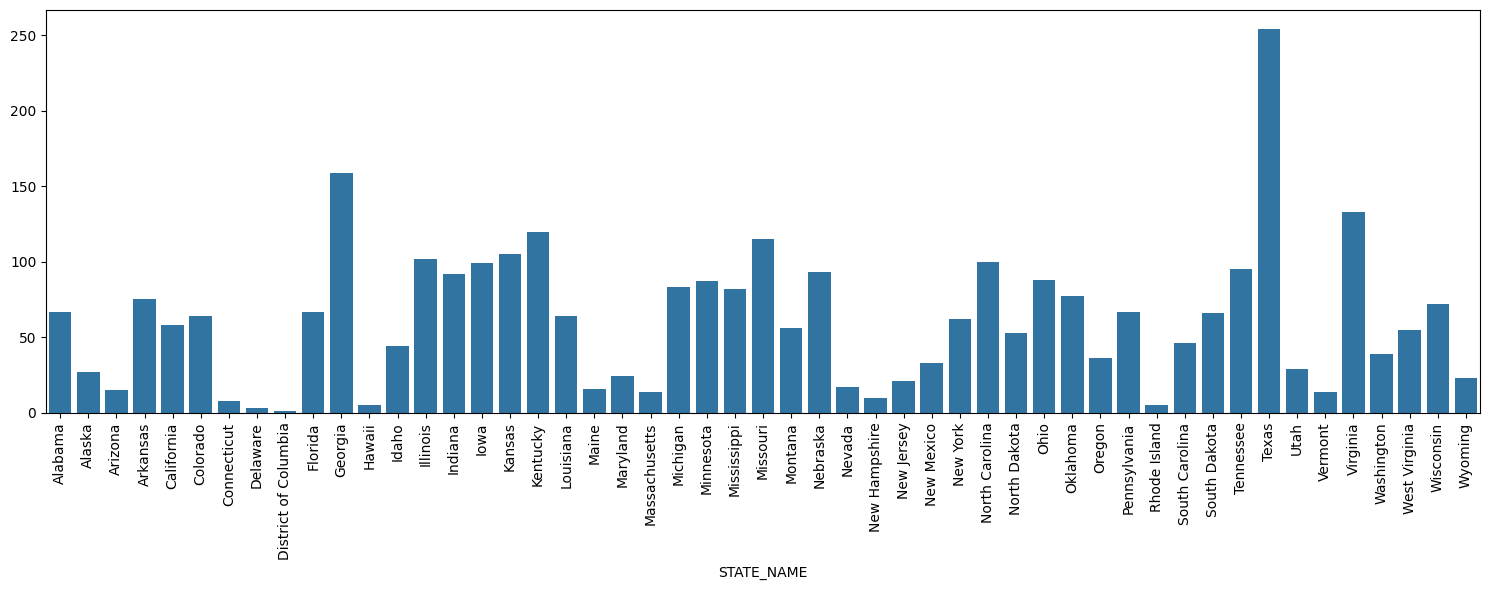

In [69]:
fig, axis = plt.subplots(1, 1, figsize=(15,6))

sns.countplot(ax=axis, data=df, x='STATE_NAME').set(ylabel=None)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [70]:
# How many counties we have
df['COUNTY_NAME'].nunique()

1841

<Axes: xlabel='COUNTY_NAME'>

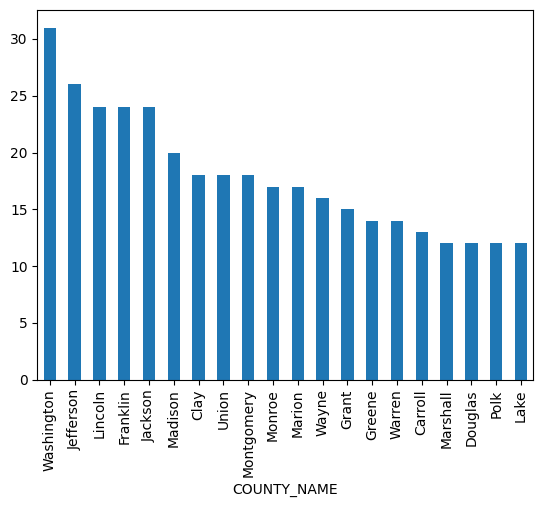

In [71]:
# Top 20 
df['COUNTY_NAME'].value_counts().head(20).plot(kind='bar')

In [72]:
# See how many different states each COUNTY_NAME has
county_state = df.groupby('COUNTY_NAME')['STATE_NAME'].nunique().sort_values(ascending=False)
county_state.head(20)


COUNTY_NAME
Washington    31
Jefferson     26
Franklin      24
Lincoln       24
Jackson       24
Madison       20
Clay          18
Montgomery    18
Union         18
Marion        17
Monroe        17
Wayne         16
Grant         15
Greene        14
Warren        14
Carroll       13
Johnson       12
Lake          12
Lee           12
Clark         12
Name: STATE_NAME, dtype: int64

> #### Observaciones: 
>
> - Texas es el valor más alto con diferencia (alrededor de 250). Varios estados pequeños o con menos población (por ejemplo Delaware, Rhode Island, Vermont) muestran valores muy bajos.
> - Washington es el nombre de condado más repetido (≈31 veces).

#### Análisis numérico-numérico

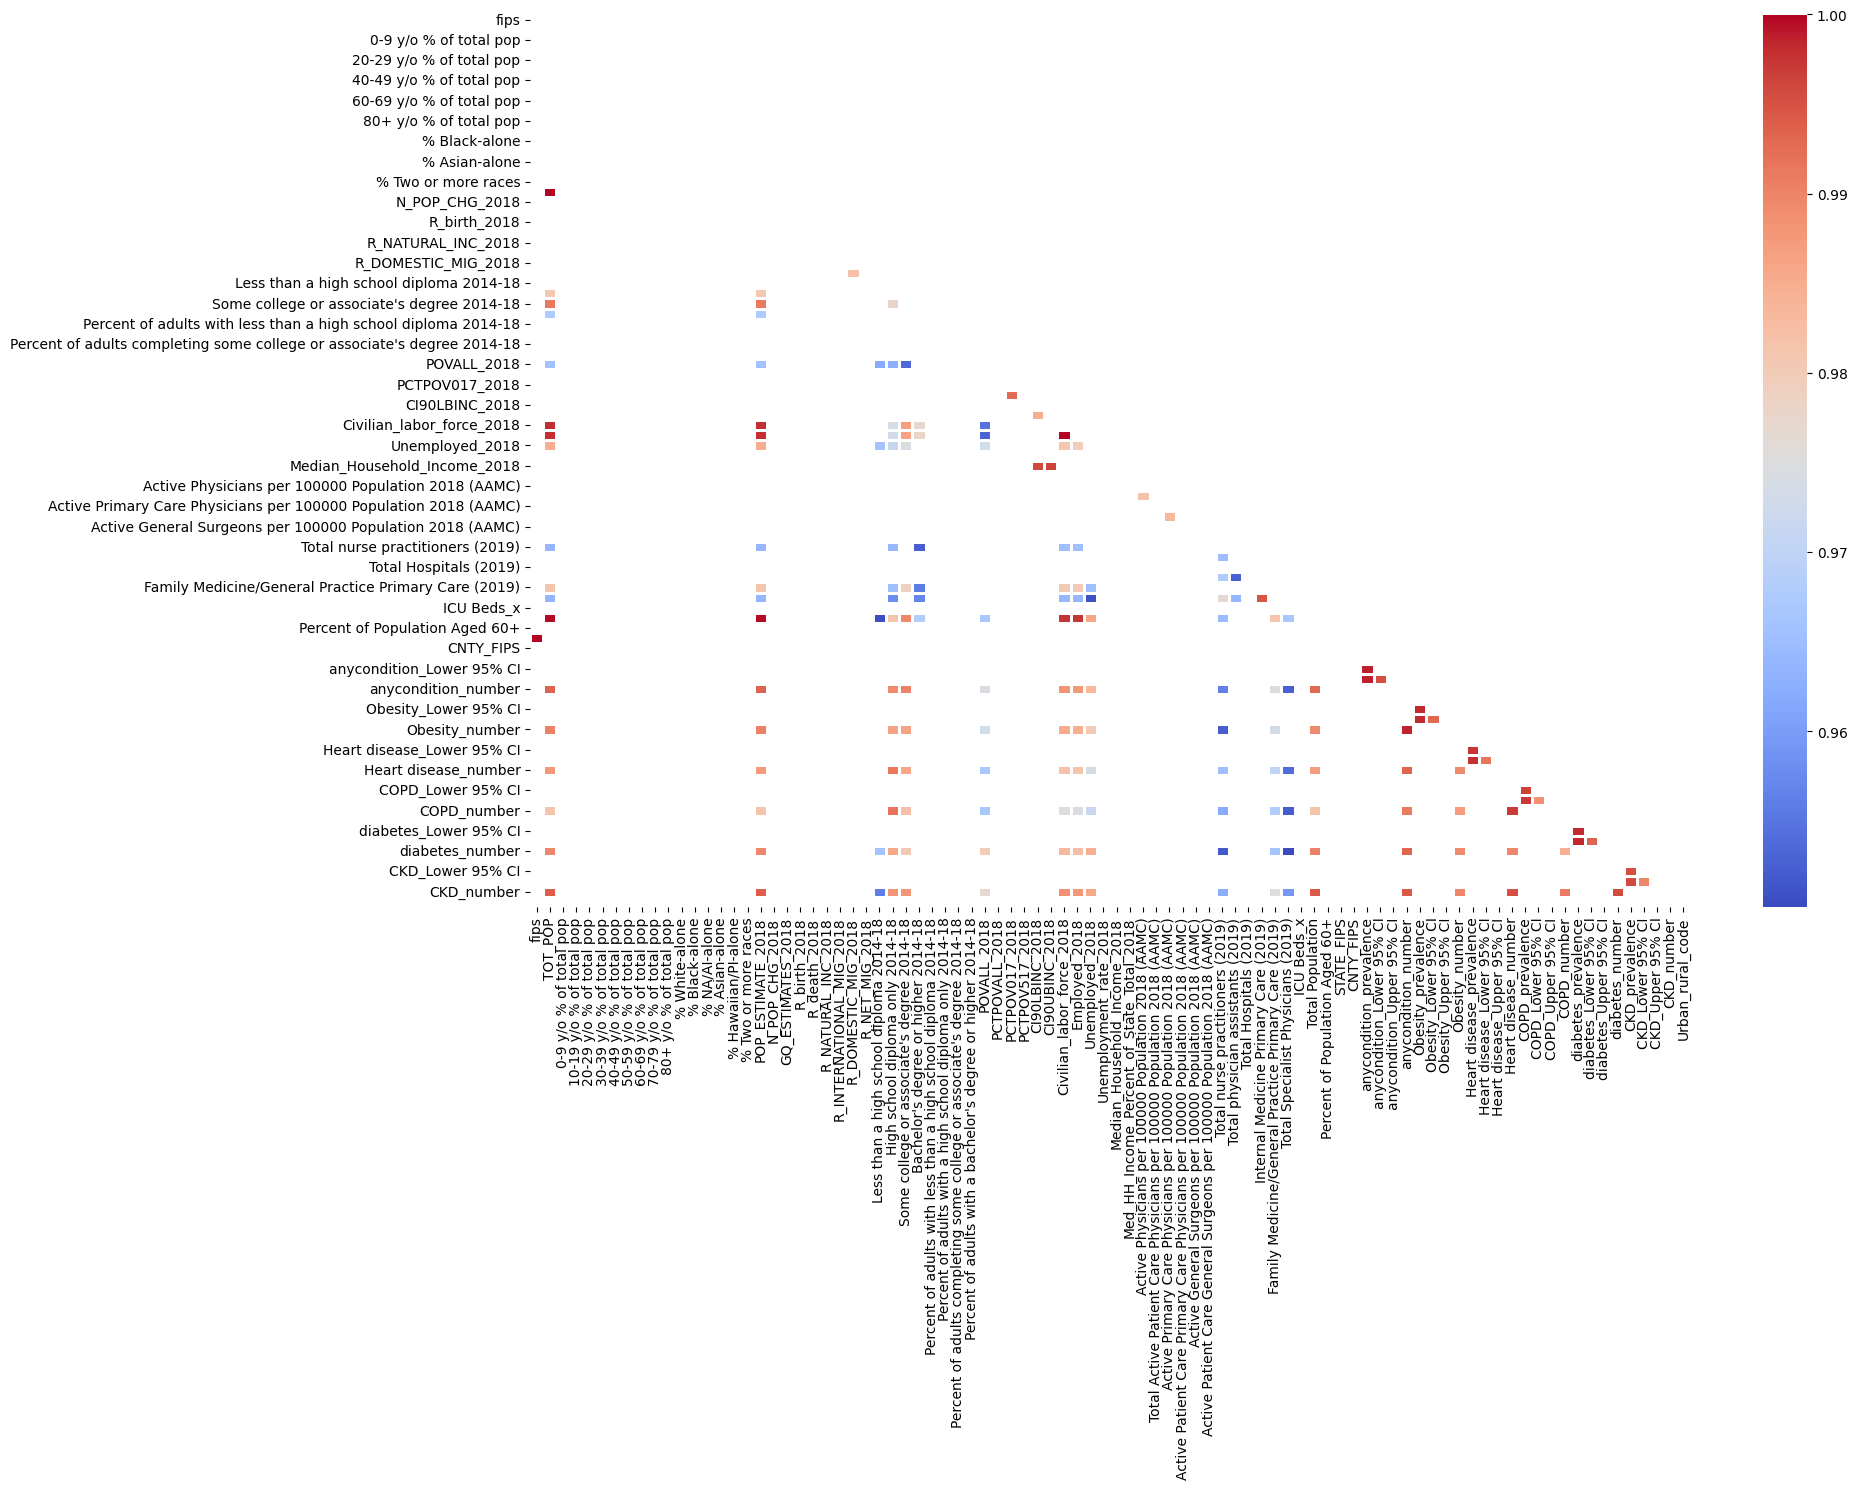

In [79]:
# Select numeric columns only
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numerical_columns.corr()
high_correlation = corr[corr > 0.95]
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(high_correlation, annot=False, mask=mask, linewidths=0.9, fmt=".2f", cmap='coolwarm')
plt.tight_layout()
plt.show()


In [80]:
# Correlations with our target
numerical_columns.corr()['ICU Beds_x'].sort_values(ascending=False)

ICU Beds_x                                                                       1.000000
COPD_number                                                                      0.922740
anycondition_number                                                              0.918752
Obesity_number                                                                   0.918087
Heart disease_number                                                             0.917757
CKD_number                                                                       0.915083
Family Medicine/General Practice Primary Care (2019)                             0.912653
Total Population                                                                 0.911363
TOT_POP                                                                          0.910824
POP_ESTIMATE_2018                                                                0.910824
Civilian_labor_force_2018                                                        0.910422
Employed_2

Conclusiones:
> Podemos eliminar la variable `MEDHHINC_2018`, porque tiene muy poca correlación con nuestro target y, al mismo tiempo, muestra una correlación muy fuerte con otras variables. También podemos eliminar `county_pop2018_18 and older` porque presenta una correlación muy alta con otras cinco variables, como `Total Population`. 

In [76]:
df.drop(['MEDHHINC_2018', 'county_pop2018_18 and older'], axis=1, inplace=True)
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Autauga,Alabama,1,1,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Baldwin,Alabama,1,3,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,4901,6486,4566,2220,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,31157,37607,8373,7940,433,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Barbour,Alabama,1,5,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,10.964286,11.